<a href="https://colab.research.google.com/github/ac5589/Pytorch-tutorial-Youtube/blob/main/tutorial_to_load_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# I have folder with blood pressure waveforms saved in my computer as .mat files.
# I want o load these data into the dtaa loader code to use the pytorch toolkit
# to implement the Machine learning algorithms

# I am using the Jupiter notebooks provided by the Google colaboratory
# for this tutorial

In [ ]:
# this segment of the code helps to load the files into google CO.
# this segment needs to be modified if running jupiter notebooks in our platforms

from google.colab import drive
drive.mount('/content/drive')

import glob, os

data_dir = '/content/drive/MyDrive/Colab Notebooks/Sample_data'
mat_files = sorted(glob.glob(os.path.join(data_dir, '*.mat')))

print(f"Found {len(mat_files)} .mat files")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 30 .mat files
['/content/drive/MyDrive/Colab Notebooks/Sample_data/1070.mat', '/content/drive/MyDrive/Colab Notebooks/Sample_data/1269.mat', '/content/drive/MyDrive/Colab Notebooks/Sample_data/1355.mat', '/content/drive/MyDrive/Colab Notebooks/Sample_data/1787.mat', '/content/drive/MyDrive/Colab Notebooks/Sample_data/201.mat']


In [ ]:
# Inspect one file

from scipy.io import loadmat

sample = loadmat(mat_files[0])

Fs = sample['Fs']
wave1 = sample['Sig_W_Airway_Pressure']
wave1

array([[0.1],
       [0.1],
       [0.1],
       ...,
       [0.1],
       [0.1],
       [0.1]])

In [ ]:
sample = loadmat(mat_files[0])
for key, value in sample.items():
    if not key.startswith('__'):
        print(key, type(value), getattr(value, 'shape', None))

Fs <class 'numpy.ndarray'> (2, 1)
Sig_N_FiO2 <class 'numpy.ndarray'> (298, 1)
Sig_N_PEEP <class 'numpy.ndarray'> (252, 1)
Sig_N_PIP <class 'numpy.ndarray'> (259, 1)
Sig_N_PlateauPressure <class 'numpy.ndarray'> (257, 1)
Sig_N_SpO2 <class 'numpy.ndarray'> (1038, 1)
Sig_N_Tidal_Volume <class 'numpy.ndarray'> (276, 1)
Sig_W_Airway_Pressure <class 'numpy.ndarray'> (135136, 1)
Sig_W_Capnography_Pressure <class 'numpy.ndarray'> (135136, 1)
anthropometric_data <class 'numpy.ndarray'> (1, 1)
case_ID <class 'numpy.ndarray'> (1, 1)
time_N_FiO2 <class 'numpy.ndarray'> (298, 1)
time_N_PEEP <class 'numpy.ndarray'> (252, 1)
time_N_PIP <class 'numpy.ndarray'> (259, 1)
time_N_PlateauPressure <class 'numpy.ndarray'> (257, 1)
time_N_SpO2 <class 'numpy.ndarray'> (1038, 1)
time_N_Tidal_Volume <class 'numpy.ndarray'> (276, 1)
time_W_Airway_Pressure <class 'numpy.ndarray'> (135136, 1)
time_W_Capnography_Pressure <class 'numpy.ndarray'> (135136, 1)


Signal shape: (135136,)
Any NaNs? False
Min/Max: -0.8 52.8
Fs values: [62.5  0. ]


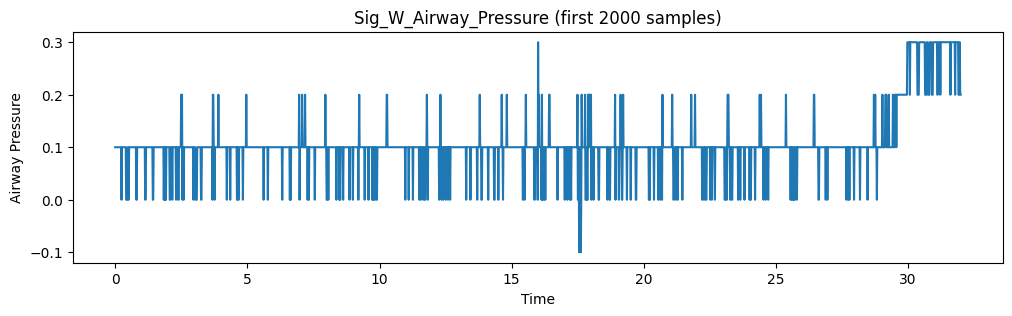

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten the signal
sig = sample['Sig_W_Airway_Pressure'].squeeze()
t = sample['time_W_Airway_Pressure'].squeeze()
fs = sample['Fs'].squeeze()

print("Signal shape:", sig.shape)
print("Any NaNs?", np.isnan(sig).any())
print("Min/Max:", sig.min(), sig.max())
print("Fs values:", fs)

plt.figure(figsize=(12, 3))
plt.plot(t[:2000], sig[:2000])  # first 2000 samples only, full signal is huge
plt.xlabel("Time")
plt.ylabel("Airway Pressure")
plt.title("Sig_W_Airway_Pressure (first 2000 samples)")
plt.show()